<a href="https://colab.research.google.com/github/A-KavyaSree/My_Game/blob/main/Code_Alpha_Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#Importing all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [10]:
# Data set upload
df = pd.read_csv("/credit_risk_dataset.csv")
print("Dataset loaded:", df.shape)

Dataset loaded: (32581, 12)


In [12]:
# STEP 1: Explore & Clean the Dataset
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"Shape         : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nTarget Distribution:")
# Changed 'SeriousDlqin2yrs' to 'loan_status'
print(df['loan_status'].value_counts())
print(f"\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nData Types:\n{df.dtypes}")
print(f"\nStatistical Summary:")
print(df.describe())

  DATASET OVERVIEW
Shape         : (32581, 12)
Columns       : ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Target Distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Missing Values:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Data Types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Statistical Summary:
         person_age  person_income

In [13]:
# Rename columns that directly map from credit_risk_dataset.csv to expected names
df.rename(columns={
    'loan_status'                : 'target',
    'person_age'                 : 'age',
    'person_income'              : 'monthly_income',
    'loan_percent_income'        : 'debt_ratio', # Using this as a proxy for debt_ratio
    'cb_person_cred_hist_length' : 'open_credit_lines', # Using this as a proxy for open credit lines
}, inplace=True)

# Create/proxy columns that are expected by the original code but are not in credit_risk_dataset.csv
# and were not handled by rename.
if 'credit_utilization' not in df.columns:
    df['credit_utilization'] = df['debt_ratio'] # Using debt_ratio as a proxy for credit_utilization

if 'real_estate_loans' not in df.columns:
    df['real_estate_loans'] = 0

if 'dependents' not in df.columns:
    df['dependents'] = 0

# Create delinquency-related columns based on 'cb_person_default_on_file'
# Assuming 'Y' means default, 'N' means no default
df['late_30_59_days'] = (df['cb_person_default_on_file'] == 'Y').astype(int) * 0.5 # A proxy value
df['late_60_89_days'] = (df['cb_person_default_on_file'] == 'Y').astype(int) * 0.75 # A proxy value
df['late_90_days']    = (df['cb_person_default_on_file'] == 'Y').astype(int) # Direct proxy for 90+ days late


In [14]:

def engineer_features(df):
    df = df.copy()

    # Total late payment events across all buckets
    df['total_late_payments'] = (
        df['late_30_59_days'] + df['late_60_89_days'] + df['late_90_days']
    )

    # Annual income
    df['annual_income'] = df['monthly_income'] * 12

    # Income per dependent (financial stress indicator)
    # Add 1 to dependents to avoid division by zero if monthly_income is non-zero and dependents is 0
    df['income_per_dependent'] = df['monthly_income'] / (df['dependents'] + 1)

    # High utilization flag (>80% is very risky)
    df['high_utilization_flag'] = (df['credit_utilization'] > 0.80).astype(int)

    # Severe delinquency flag (ever 90+ days late)
    df['severe_delinquency'] = (df['late_90_days'] > 0).astype(int)

    # Total credit exposure
    df['total_credit_lines'] = df['open_credit_lines'] + df['real_estate_loans']

    # Cap extreme outliers in utilization
    df['credit_utilization'] = df['credit_utilization'].clip(0, 1)

    # Cap extreme debt ratios
    df['debt_ratio'] = df['debt_ratio'].clip(0, 5)

    return df

df = engineer_features(df)
print(f"\nFeatures after engineering: {df.shape[1]}")

# Convert target to numeric
# Assuming 'loan_status' values are '0' for no default and '1' for default
# If they are 'Y'/'N' or other strings, this needs adjustment
df['target'] = df['target'].astype(int)




Features after engineering: 24


In [15]:
feature_cols = [
    'credit_utilization', 'age', 'late_30_59_days', 'debt_ratio',
    'monthly_income', 'open_credit_lines', 'late_90_days',
    'real_estate_loans', 'late_60_89_days', 'dependents',
    'total_late_payments', 'annual_income', 'income_per_dependent',
    'high_utilization_flag', 'severe_delinquency', 'total_credit_lines'
]

X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"Class balance (train): {y_train.mean():.2%} defaulted")




Train size : 26064
Test size  : 6517
Class balance (train): 21.82% defaulted


In [21]:
def build_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

models = {
    'Logistic Regression': build_pipeline(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    ),
    'Decision Tree': build_pipeline(
        DecisionTreeClassifier(max_depth=6, min_samples_split=20,
                               random_state=42, class_weight='balanced')
    ),
    'Random Forest': build_pipeline(
        RandomForestClassifier(n_estimators=200, max_depth=8,
                               random_state=42, class_weight='balanced', n_jobs=-1)
    ),
    'Gradient Boosting': build_pipeline(
        GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                   max_depth=4, random_state=42)
    ),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("  MODEL TRAINING & EVALUATION")
print("=" * 60)

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline' : pipeline,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'CV F1'    : cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1').mean()
    }

    r = results[name]
    print(f"\n  ── {name}")
    print(f"     Accuracy={r['Accuracy']:.4f}  Precision={r['Precision']:.4f}  "
          f"Recall={r['Recall']:.4f}  F1={r['F1-Score']:.4f}  AUC={r['ROC-AUC']:.4f}")
    # Updated target_names for classification report
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))



  MODEL TRAINING & EVALUATION

  ── Logistic Regression
     Accuracy=0.7240  Precision=0.4190  Recall=0.6857  F1=0.5201  AUC=0.7727
              precision    recall  f1-score   support

  No Default       0.89      0.73      0.81      5095
     Default       0.42      0.69      0.52      1422

    accuracy                           0.72      6517
   macro avg       0.66      0.71      0.66      6517
weighted avg       0.79      0.72      0.74      6517


  ── Decision Tree
     Accuracy=0.7766  Precision=0.4916  Recall=0.7032  F1=0.5787  AUC=0.8087
              precision    recall  f1-score   support

  No Default       0.91      0.80      0.85      5095
     Default       0.49      0.70      0.58      1422

    accuracy                           0.78      6517
   macro avg       0.70      0.75      0.71      6517
weighted avg       0.82      0.78      0.79      6517


  ── Random Forest
     Accuracy=0.7907  Precision=0.5156  Recall=0.6758  F1=0.5849  AUC=0.8238
              prec

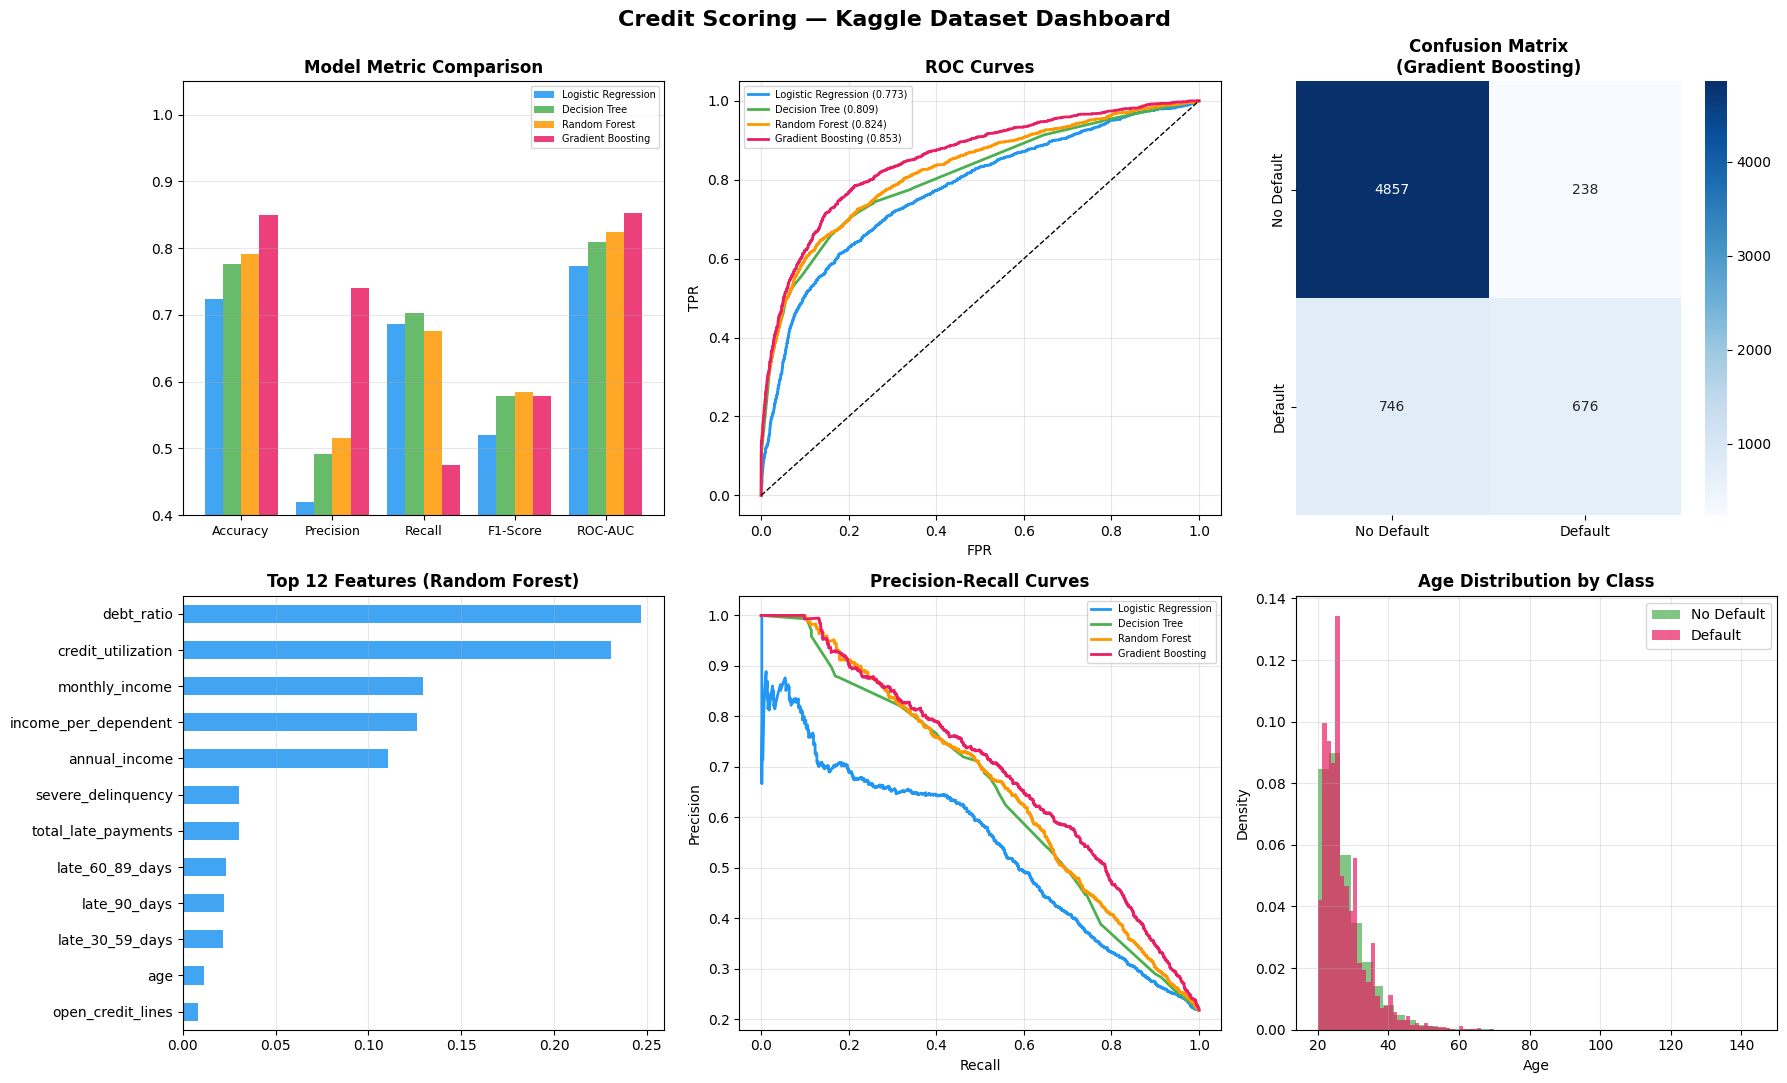


Dashboard saved.


In [22]:
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Credit Scoring — Kaggle Dataset Dashboard', fontsize=16, fontweight='bold')

# Metric comparison
ax = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
w = 0.2
for i, (name, res) in enumerate(results.items()):
    ax.bar(x + i * w, [res[m] for m in metrics], w, label=name, color=colors[i], alpha=0.85)
ax.set_xticks(x + w * 1.5); ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim(0.4, 1.05); ax.set_title('Model Metric Comparison', fontweight='bold')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

# ROC Curves
ax = axes[0, 1]
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f"{name} ({res['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Confusion Matrix — Best Model
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
ax = axes[0, 2]
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default']) # Updated labels
ax.set_title(f'Confusion Matrix\n({best_name})', fontweight='bold')

# Feature Importance
ax = axes[1, 0]
rf = results['Random Forest']['pipeline'].named_steps['model']
pd.Series(rf.feature_importances_, index=feature_cols).nlargest(12).sort_values()\
  .plot(kind='barh', ax=ax, color='#2196F3', alpha=0.85)
ax.set_title('Top 12 Features (Random Forest)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Precision-Recall
ax = axes[1, 1]
for i, (name, res) in enumerate(results.items()):
    p, r, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(r, p, color=colors[i], lw=2, label=name)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Age distribution by class
ax = axes[1, 2]
# Updated labels for the age distribution plot
ax.hist(df[df['target'] == 0]['age'], bins=40, alpha=0.7, color='#4CAF50',
        label='No Default', density=True)
ax.hist(df[df['target'] == 1]['age'], bins=40, alpha=0.7, color='#E91E63',
        label='Default', density=True)
ax.set_xlabel('Age'); ax.set_ylabel('Density')
ax.set_title('Age Distribution by Class', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('credit_scoring_kaggle_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDashboard saved.")

In [23]:
summary = pd.DataFrame({
    n: {k: v for k, v in r.items() if k not in ('pipeline', 'y_pred', 'y_prob')}
    for n, r in results.items()
}).T

print("\n" + "=" * 60)
print("  FINAL MODEL SUMMARY")
print("=" * 60)
print(summary.round(4).to_string())
print(f"\n★  Best Model: {best_name}  (ROC-AUC = {results[best_name]['ROC-AUC']:.4f})")


  FINAL MODEL SUMMARY
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC   CV F1
Logistic Regression    0.7240     0.4190  0.6857    0.5201   0.7727  0.5204
Decision Tree          0.7766     0.4916  0.7032    0.5787   0.8087  0.5791
Random Forest          0.7907     0.5156  0.6758    0.5849   0.8238  0.5872
Gradient Boosting      0.8490     0.7396  0.4754    0.5788   0.8528  0.5831

★  Best Model: Gradient Boosting  (ROC-AUC = 0.8528)
